# 04. 대표 K-ETS VWAP 타겟 정책 결정

`00_vintage_rule`, `01_ets_eda`, `02_vintage_rule_eda`, `03_target_eda`의 결과를 바탕으로 모델링용 타겟 정책을 정리한다.

목표는 `탄소배출권 가격 예측 및 결정 모형`이라는 주제에 맞게, 날짜별 K-ETS 가격을 어떻게 정의하고 어떤 예측 기간 수익률을 예측할지 결정하는 것이다.

현재 판단에서는 날짜마다 특정 빈티지 하나를 고르는 방식을 대표 시계열 생성 규칙으로 사용하지 않는다. 빈티지 선택이 자주 바뀌면 단일 가격 시계열로 해석하기 어렵기 때문이다. 이 노트북에서는 같은 날 여러 KAU 빈티지가 거래된 경우, 해당 날짜의 실제 거래를 모두 합친 **전체 거래 VWAP**(`market_vwap`)를 검토한다.

이 단계에서는 `raw.krx_ets_daily`만 사용한다. GIR, EPSIS/KPX, KMA, 정책 이벤트, 거시 지표는 후속 feature engineering 단계에서 붙인다. `data/processed` 저장은 하지 않고, 정책과 검증 결과만 노트북 출력으로 확인한다.

## 예측 타겟 정의

| 개념 | 의미 |
|---|---|
| `market_vwap` | 같은 날짜에 실제 거래된 KAU 빈티지들의 VWAP를 거래량으로 합친 전체 거래 VWAP |
| `future_vwap_30d/60d` | 기준일에서 30일 또는 60일이 지난 뒤 처음 관측되는 `market_vwap` |
| `target_logret_30d/60d` | 기준일 `market_vwap` 대비 미래 `market_vwap`의 로그수익률 |

In [42]:
# 1. 환경 설정
from pathlib import Path
import os
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from dotenv import load_dotenv
from sqlalchemy import create_engine

if Path('/mnt/hgfs/Windows/Climate').exists():
    PROJECT_ROOT = Path('/mnt/hgfs/Windows/Climate')
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

SAVE_OUTPUT = False

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
plt.rcParams['axes.unicode_minus'] = False

In [43]:
# 2. DB 연결 및 KRX ETS 원천 데이터 로드
load_dotenv(PROJECT_ROOT / '.env')
required_keys = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing = [key for key in required_keys if not os.getenv(key)]
if missing:
    raise RuntimeError(f'필수 DB 환경변수가 없습니다: {missing}')

user = os.getenv('DB_USER')
password = quote_plus(os.getenv('DB_PASSWORD'))
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}')

query = """
select
    period,
    trd_dd,
    isu_code,
    clsprc,
    acc_trdvol,
    acc_trdval,
    vwap
from raw.krx_ets_daily
order by trd_dd, isu_code
"""

ets = pd.read_sql(query, engine, parse_dates=['trd_dd'])
ets['isu_year'] = ets['isu_code'].str.extract(r'(\d{2})$')[0].astype('Int64') + 2000
ets['is_trade_day'] = (ets['acc_trdvol'] > 0) & (ets['vwap'] > 0)
ets_trade = ets[ets['is_trade_day']].copy().sort_values(['trd_dd', 'isu_code']).reset_index(drop=True)

trade_vintage_count_by_date = ets_trade.groupby('trd_dd')['isu_code'].nunique()
source_summary = pd.DataFrame({
    '항목': [
        'raw.krx_ets_daily 전체 행 수',
        '실제 거래 행 수',
        '전체 거래일 수',
        '실제 거래가 있는 날짜 수',
        '시작일',
        '종료일',
        '실제 거래 빈티지 수',
        '동일 날짜 2개 이상 빈티지 거래일 수',
        '동일 날짜 최대 실제 거래 빈티지 수',
    ],
    '값': [
        len(ets),
        len(ets_trade),
        ets['trd_dd'].nunique(),
        ets_trade['trd_dd'].nunique(),
        ets['trd_dd'].min().date(),
        ets['trd_dd'].max().date(),
        ets_trade['isu_code'].nunique(),
        int((trade_vintage_count_by_date >= 2).sum()),
        int(trade_vintage_count_by_date.max()),
    ],
})
source_summary

,항목,값
0,raw.krx_ets_daily 전체 행 수,8213
1,실제 거래 행 수,2385
2,전체 거래일 수,2770
3,실제 거래가 있는 날짜 수,2132
4,시작일,2015-01-12
5,종료일,2026-04-23
6,실제 거래 빈티지 수,11
7,동일 날짜 2개 이상 빈티지 거래일 수,252
8,동일 날짜 최대 실제 거래 빈티지 수,3


In [ ]:
# 3. 전체 거래 VWAP 생성
# 같은 날짜에 여러 KAU 빈티지가 거래되면 해당 날짜의 실제 거래를 모두 합쳐 하나의 VWAP를 만든다.
# 이 방식은 날짜별 K-ETS 가격을 집계하는 규칙이다.

def join_codes(codes):
    return ','.join(sorted(codes))

market_base = ets_trade.assign(
    weighted_vwap_value=ets_trade['vwap'] * ets_trade['acc_trdvol']
)

market_daily = (
    market_base
    .groupby('trd_dd', as_index=False)
    .agg(
        market_vwap=('weighted_vwap_value', 'sum'),
        total_trdvol=('acc_trdvol', 'sum'),
        total_trdval=('acc_trdval', 'sum'),
        n_vintages=('isu_code', 'nunique'),
        vintages=('isu_code', join_codes),
    )
    .sort_values('trd_dd')
    .reset_index(drop=True)
)
market_daily['market_vwap'] = market_daily['market_vwap'] / market_daily['total_trdvol']
market_daily['vwap_from_trdval'] = market_daily['total_trdval'] / market_daily['total_trdvol']
market_daily['vwap_check_abs_diff'] = (market_daily['market_vwap'] - market_daily['vwap_from_trdval']).abs()
market_daily['is_blended'] = market_daily['n_vintages'] >= 2
market_daily['price_policy'] = 'market_vwap'

policy_input_summary = pd.DataFrame({
    '항목': [
        '전체 거래 VWAP 관측치 수',
        '전체 거래 VWAP 시작일',
        '전체 거래 VWAP 종료일',
        '2개 이상 빈티지를 합친 날짜 수',
        '2개 이상 빈티지를 합친 날짜 비율',
        '동일 날짜 최대 실제 거래 빈티지 수',
        '거래대금 기반 VWAP와의 최대 절대 차이',
    ],
    '값': [
        len(market_daily),
        market_daily['trd_dd'].min().date(),
        market_daily['trd_dd'].max().date(),
        int(market_daily['is_blended'].sum()),
        market_daily['is_blended'].mean(),
        int(market_daily['n_vintages'].max()),
        market_daily['vwap_check_abs_diff'].max(),
    ],
})
policy_input_summary

,항목,값
0,전체 거래 VWAP 관측치 수,2132
1,전체 거래 VWAP 시작일,2015-01-12
2,전체 거래 VWAP 종료일,2026-04-23
3,2개 이상 빈티지를 합친 날짜 수,252
4,2개 이상 빈티지를 합친 날짜 비율,0.118199
5,동일 날짜 최대 실제 거래 빈티지 수,3
6,거래대금 기반 VWAP와의 최대 절대 차이,0.5


In [ ]:
# 4. 겹치는 빈티지 거래일 확인
# 전체 거래 VWAP가 여러 빈티지를 합쳐 계산된 날짜의 예시만 확인한다.
blended_days_display = market_daily[market_daily['is_blended']].copy()
blended_days_display = blended_days_display[[
    'trd_dd',
    'vintages',
    'n_vintages',
    'market_vwap',
    'total_trdvol',
]].head(20).rename(columns={
    'trd_dd': '거래일',
    'vintages': '포함 빈티지',
    'n_vintages': '거래 빈티지 수',
    'market_vwap': '전체 거래 VWAP',
    'total_trdvol': '전체 거래량',
})

blended_days_display.style.format({
    '전체 거래 VWAP': '{:,.2f}',
    '전체 거래량': '{:,.0f}',
})

,거래일,포함 빈티지,거래 빈티지 수,전체 거래 VWAP,전체 거래량
79,2017-02-06 00:00:00,"KAU16,KAU17",2,"25,964.55","7,746"
95,2017-03-06 00:00:00,"KAU16,KAU17",2,"23,210.45","35,032"
97,2017-03-09 00:00:00,"KAU16,KAU17",2,"22,628.57","35,000"
102,2017-03-16 00:00:00,"KAU16,KAU17",2,"21,400.00","125,000"
104,2017-03-20 00:00:00,"KAU16,KAU17",2,"20,784.62","13,000"
115,2017-04-04 00:00:00,"KAU16,KAU17",2,"20,603.34","290,000"
117,2017-04-06 00:00:00,"KAU16,KAU17",2,"20,589.00","45,000"
120,2017-04-11 00:00:00,"KAU16,KAU17",2,"20,473.99","217,000"
121,2017-04-12 00:00:00,"KAU16,KAU17",2,"20,447.05","241,590"
122,2017-04-13 00:00:00,"KAU16,KAU17",2,"20,440.29","103,000"


In [ ]:
# 5. 전체 거래 VWAP forward return 생성 함수
# 기준일 + 예측 기간 이후 첫 전체 거래 VWAP 관측치를 미래 가격으로 사용한다.

def add_forward_return_targets(price_df, target_periods=(30, 60)):
    result = price_df.copy().sort_values('trd_dd').reset_index(drop=True)
    result['trd_dd'] = pd.to_datetime(result['trd_dd']).astype('datetime64[ns]')
    future_base_cols = [
        'trd_dd',
        'market_vwap',
        'total_trdvol',
        'n_vintages',
        'is_blended',
    ]
    future_base = result[future_base_cols].copy()
    
    for target_period in target_periods:
        future = future_base.rename(columns={
            'trd_dd': f'future_date_{target_period}d',
            'market_vwap': f'future_vwap_{target_period}d',
            'total_trdvol': f'future_trdvol_{target_period}d',
            'n_vintages': f'future_n_vintages_{target_period}d',
            'is_blended': f'future_is_blended_{target_period}d',
        }).sort_values(f'future_date_{target_period}d')
        
        lookup = result[['trd_dd']].copy()
        lookup['_row_id'] = np.arange(len(lookup))
        lookup[f'target_lookup_date_{target_period}d'] = lookup['trd_dd'] + pd.Timedelta(days=target_period)
        lookup[f'target_lookup_date_{target_period}d'] = pd.to_datetime(lookup[f'target_lookup_date_{target_period}d']).astype('datetime64[ns]')
        future[f'future_date_{target_period}d'] = pd.to_datetime(future[f'future_date_{target_period}d']).astype('datetime64[ns]')
        lookup = lookup.sort_values(f'target_lookup_date_{target_period}d')
        
        matched = pd.merge_asof(
            lookup,
            future,
            left_on=f'target_lookup_date_{target_period}d',
            right_on=f'future_date_{target_period}d',
            direction='forward',
        ).sort_values('_row_id')
        
        for col in [
            f'target_lookup_date_{target_period}d',
            f'future_date_{target_period}d',
            f'future_vwap_{target_period}d',
            f'future_trdvol_{target_period}d',
            f'future_n_vintages_{target_period}d',
            f'future_is_blended_{target_period}d',
        ]:
            result[col] = matched[col].values
        
        result[f'actual_elapsed_days_{target_period}d'] = (
            result[f'future_date_{target_period}d'] - result['trd_dd']
        ).dt.days
        result[f'target_logret_{target_period}d'] = np.log(
            result[f'future_vwap_{target_period}d'] / result['market_vwap']
        )
        result[f'target_direction_{target_period}d'] = np.where(
            result[f'target_logret_{target_period}d'].isna(),
            pd.NA,
            (result[f'target_logret_{target_period}d'] > 0).astype('Int64'),
        )
    return result

target_df = add_forward_return_targets(market_daily, target_periods=(30, 60))
target_df.head()

,trd_dd,market_vwap,total_trdvol,total_trdval,n_vintages,vintages,vwap_from_trdval,vwap_check_abs_diff,is_blended,price_policy,target_lookup_date_30d,future_date_30d,future_vwap_30d,future_trdvol_30d,future_n_vintages_30d,future_is_blended_30d,actual_elapsed_days_30d,target_logret_30d,target_direction_30d,target_lookup_date_60d,future_date_60d,future_vwap_60d,future_trdvol_60d,future_n_vintages_60d,future_is_blended_60d,actual_elapsed_days_60d,target_logret_60d,target_direction_60d
0,2015-01-12,8185.0,1190,9740400,1,KAU15,8185.210084,0.210084,False,market_vwap,2015-02-11,2015-10-07,11300.0,12000.0,1.0,False,268.0,0.322500,1,2015-03-13,2015-10-07,11300.0,12000.0,1.0,False,268.0,0.322500,1
1,2015-01-13,9500.0,50,475000,1,KAU15,9500.000000,0.000000,False,market_vwap,2015-02-12,2015-10-07,11300.0,12000.0,1.0,False,267.0,0.173511,1,2015-03-14,2015-10-07,11300.0,12000.0,1.0,False,267.0,0.173511,1
2,2015-01-14,9510.0,100,951000,1,KAU15,9510.000000,0.000000,False,market_vwap,2015-02-13,2015-10-07,11300.0,12000.0,1.0,False,266.0,0.172459,1,2015-03-15,2015-10-07,11300.0,12000.0,1.0,False,266.0,0.172459,1
3,2015-01-16,9610.0,40,384400,1,KAU15,9610.000000,0.000000,False,market_vwap,2015-02-15,2015-10-07,11300.0,12000.0,1.0,False,264.0,0.161999,1,2015-03-17,2015-10-07,11300.0,12000.0,1.0,False,264.0,0.161999,1
4,2015-10-07,11300.0,12000,135600000,1,KAU15,11300.000000,0.000000,False,market_vwap,2015-11-06,2015-12-09,12100.0,100000.0,1.0,False,63.0,0.068403,1,2015-12-06,2015-12-09,12100.0,100000.0,1.0,False,63.0,0.068403,1


In [47]:
# 6. 전체 거래 VWAP forward return coverage와 분포
summary_rows = []
for target_period in [30, 60]:
    target_col = f'target_logret_{target_period}d'
    elapsed_col = f'actual_elapsed_days_{target_period}d'
    valid = target_df[target_col].notna()
    x = target_df.loc[valid, target_col]
    elapsed_days = target_df.loc[valid, elapsed_col]
    summary_rows.append({
        'target': target_col,
        'base_obs': len(target_df),
        'target_obs': int(valid.sum()),
        'coverage': valid.mean(),
        'actual_elapsed_median_days': elapsed_days.median(),
        'actual_elapsed_p95_days': elapsed_days.quantile(0.95),
        'actual_elapsed_max_days': elapsed_days.max(),
        'mean': x.mean(),
        'std': x.std(),
        'min': x.min(),
        'median': x.median(),
        'max': x.max(),
        'positive_rate': (x > 0).mean(),
        'base_blended_rate': target_df.loc[valid, 'is_blended'].mean(),
        'future_blended_rate': target_df.loc[valid, f'future_is_blended_{target_period}d'].mean(),
    })

forward_return_summary = pd.DataFrame(summary_rows)
forward_return_display = forward_return_summary.rename(columns={
    'target': '타겟',
    'base_obs': '기준 관측치 수',
    'target_obs': '타겟 생성 수',
    'coverage': '생성률',
    'actual_elapsed_median_days': '실제 경과일 중앙값',
    'actual_elapsed_p95_days': '실제 경과일 95% 분위',
    'actual_elapsed_max_days': '실제 경과일 최대값',
    'mean': '평균',
    'std': '표준편차',
    'min': '최소',
    'median': '중앙값',
    'max': '최대',
    'positive_rate': '상승 비율',
    'base_blended_rate': '기준일 blended 비율',
    'future_blended_rate': '미래일 blended 비율',
})
forward_return_display.style.format({
    '생성률': '{:.1%}',
    '실제 경과일 중앙값': '{:.0f}',
    '실제 경과일 95% 분위': '{:.0f}',
    '실제 경과일 최대값': '{:.0f}',
    '평균': '{:.4f}',
    '표준편차': '{:.4f}',
    '최소': '{:.4f}',
    '중앙값': '{:.4f}',
    '최대': '{:.4f}',
    '상승 비율': '{:.1%}',
    '기준일 blended 비율': '{:.1%}',
    '미래일 blended 비율': '{:.1%}',
})


,타겟,기준 관측치 수,타겟 생성 수,생성률,실제 경과일 중앙값,실제 경과일 95% 분위,실제 경과일 최대값,평균,표준편차,최소,중앙값,최대,상승 비율,기준일 blended 비율,미래일 blended 비율
0,target_logret_30d,2132,2110,99.0%,30,34,268,-0.0030,0.1447,-0.6070,0.0048,0.7201,52.7%,11.9%,11.4%
1,target_logret_60d,2132,2089,98.0%,60,64,268,-0.0065,0.2034,-0.6458,0.0013,0.9637,50.4%,12.1%,11.1%


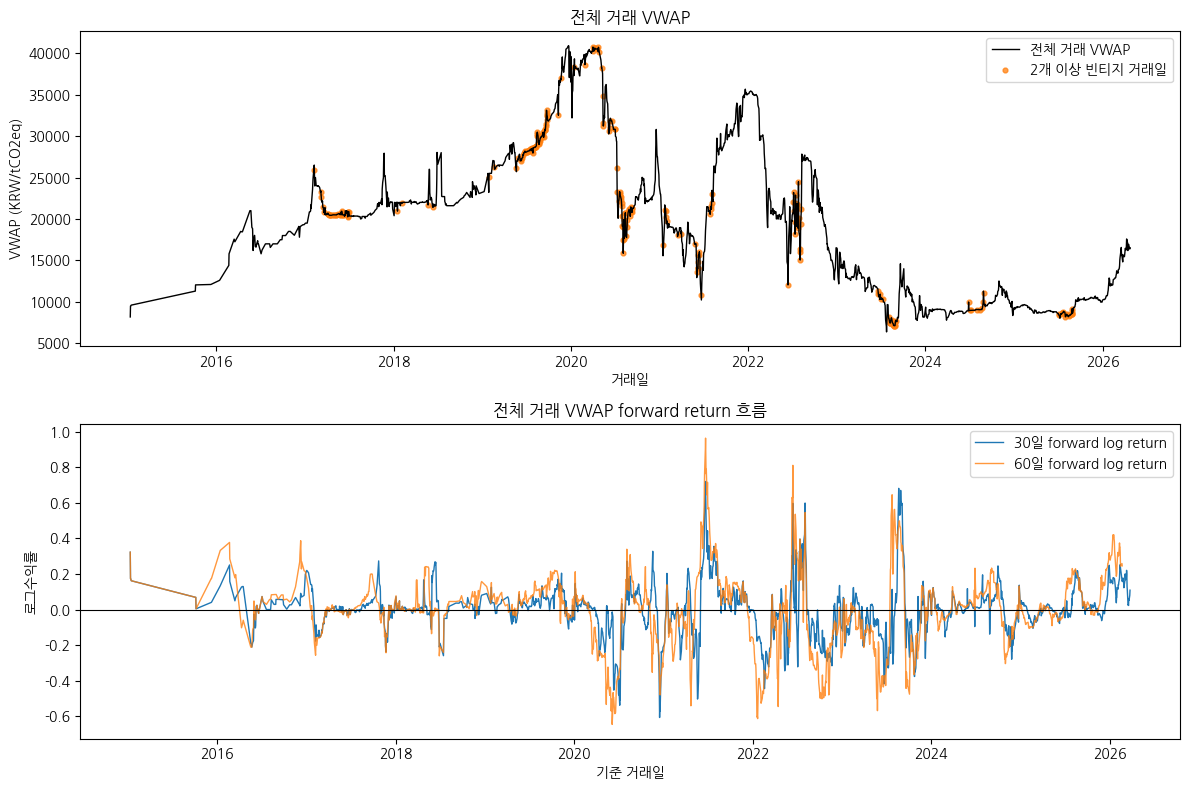

In [52]:
# 7. 전체 거래 VWAP와 forward return 시각화
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(target_df['trd_dd'], target_df['market_vwap'], color='black', linewidth=1.0, label='전체 거래 VWAP')
blended_points = target_df[target_df['is_blended']]
axes[0].scatter(blended_points['trd_dd'], blended_points['market_vwap'], s=12, color='tab:orange', alpha=0.75, label='2개 이상 빈티지 거래일')
axes[0].set_title('전체 거래 VWAP')
axes[0].set_xlabel('거래일')
axes[0].set_ylabel('VWAP (KRW/tCO2eq)')
axes[0].legend()

axes[1].plot(target_df['trd_dd'], target_df['target_logret_30d'], label='30일 forward log return', linewidth=1.0)
axes[1].plot(target_df['trd_dd'], target_df['target_logret_60d'], label='60일 forward log return', linewidth=1.0, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('전체 거래 VWAP forward return 흐름')
axes[1].set_xlabel('기준 거래일')
axes[1].set_ylabel('로그수익률')
axes[1].legend()

fig.tight_layout()
plt.show()

In [49]:
# 8. volume-confirmed roll 후보를 정책 비교용으로 재계산
# rolling_window=20, confirm_days=5, min_next_volume=1_000.

def adjacent_pairs(codes):
    years = pd.Series(codes).str.extract(r'(\d{2})$')[0].astype(int) + 2000
    pairs = pd.DataFrame({'isu_code': list(codes), 'isu_year': years}).sort_values('isu_year').reset_index(drop=True)
    rows = []
    for i in range(len(pairs) - 1):
        cur = pairs.iloc[i]
        nxt = pairs.iloc[i + 1]
        if int(nxt['isu_year']) == int(cur['isu_year']) + 1:
            rows.append((cur['isu_code'], nxt['isu_code']))
    return rows


def build_pair_overlap(df, current_code, next_code):
    cur = df[df['isu_code'] == current_code][['trd_dd', 'acc_trdvol', 'vwap']].rename(columns={
        'acc_trdvol': 'current_volume',
        'vwap': 'current_vwap',
    })
    nxt = df[df['isu_code'] == next_code][['trd_dd', 'acc_trdvol', 'vwap']].rename(columns={
        'acc_trdvol': 'next_volume',
        'vwap': 'next_vwap',
    })
    overlap = cur.merge(nxt, on='trd_dd', how='inner').sort_values('trd_dd').reset_index(drop=True)
    overlap['current_code'] = current_code
    overlap['next_code'] = next_code
    overlap['pair'] = f'{current_code}->{next_code}'
    return overlap


def find_volume_confirmed_roll(overlap, rolling_window=20, confirm_days=5, min_next_volume=1_000):
    g = overlap.sort_values('trd_dd').copy()
    g['current_volume_roll'] = g['current_volume'].rolling(rolling_window, min_periods=1).sum()
    g['next_volume_roll'] = g['next_volume'].rolling(rolling_window, min_periods=1).sum()
    g['roll_signal'] = (g['next_volume_roll'] > g['current_volume_roll']) & (g['next_volume'] >= min_next_volume)
    g['roll_signal_run'] = (
        g['roll_signal'].astype(int)
        .groupby((~g['roll_signal']).cumsum())
        .cumsum()
    )
    candidates = g[g['roll_signal_run'] >= confirm_days]
    if candidates.empty:
        return None, g
    row = candidates.iloc[0]
    post = g[g['trd_dd'] >= row['trd_dd']].copy()
    out = {
        'pair': row['pair'],
        'roll_candidate_date': row['trd_dd'],
        'current_rolling_volume': row['current_volume_roll'],
        'next_rolling_volume': row['next_volume_roll'],
        'current_volume': row['current_volume'],
        'next_volume': row['next_volume'],
        'price_ratio_next_current': row['next_vwap'] / row['current_vwap'],
        'log_price_gap': np.log(row['next_vwap'] / row['current_vwap']),
        'post_overlap_days': len(post),
        'post_next_rolling_win_rate': (post['next_volume_roll'] > post['current_volume_roll']).mean() if len(post) else np.nan,
    }
    return out, g

pair_rows = []
roll_rows = []
for current_code, next_code in adjacent_pairs(sorted(ets_trade['isu_code'].unique())):
    overlap = build_pair_overlap(ets_trade, current_code, next_code)
    if overlap.empty:
        pair_rows.append({
            'pair': f'{current_code}->{next_code}',
            'overlap_trade_days': 0,
            'next_daily_volume_win_rate': np.nan,
        })
        continue
    pair_rows.append({
        'pair': f'{current_code}->{next_code}',
        'overlap_trade_days': len(overlap),
        'start_date': overlap['trd_dd'].min(),
        'end_date': overlap['trd_dd'].max(),
        'next_daily_volume_win_rate': (overlap['next_volume'] > overlap['current_volume']).mean(),
    })
    candidate, _ = find_volume_confirmed_roll(overlap)
    if candidate is not None:
        roll_rows.append(candidate)

pair_overlap_summary = pd.DataFrame(pair_rows)
roll_candidate_summary = pd.DataFrame(roll_rows)

roll_candidate_display = roll_candidate_summary.copy()
if not roll_candidate_display.empty:
    roll_candidate_display['roll_candidate_date'] = roll_candidate_display['roll_candidate_date'].dt.date
    roll_candidate_display = roll_candidate_display.rename(columns={
        'pair': 'pair',
        'roll_candidate_date': '전환 후보일',
        'current_rolling_volume': '현재 rolling 거래량',
        'next_rolling_volume': '다음 rolling 거래량',
        'current_volume': '후보일 현재 거래량',
        'next_volume': '후보일 다음 거래량',
        'price_ratio_next_current': '가격비율 next/current',
        'log_price_gap': 'log price gap',
        'post_overlap_days': '후보일 이후 overlap 일수',
        'post_next_rolling_win_rate': '후보일 이후 next 우위 비율',
    })
roll_candidate_display

,pair,전환 후보일,현재 rolling 거래량,다음 rolling 거래량,후보일 현재 거래량,후보일 다음 거래량,가격비율 next/current,log price gap,후보일 이후 overlap 일수,후보일 이후 next 우위 비율
0,KAU19->KAU20,2020-04-09,157209.0,218588.0,36000,5000,1.02497,0.024663,52,0.192308


In [ ]:
# 9. 타겟 정책 후보 비교표
main_coverage_30 = forward_return_summary.loc[forward_return_summary['target'].eq('target_logret_30d'), 'coverage'].iloc[0]
main_coverage_60 = forward_return_summary.loc[forward_return_summary['target'].eq('target_logret_60d'), 'coverage'].iloc[0]
blended_days = int(market_daily['is_blended'].sum())
blended_rate = market_daily['is_blended'].mean()
roll_count = len(roll_candidate_summary)
roll_post_win = roll_candidate_summary['post_next_rolling_win_rate'].iloc[0] if roll_count else np.nan

policy_scorecard = pd.DataFrame([
    {
        'target_policy': 'market_vwap',
        'unit': 'trd_dd',
        'target_definition': 'log(future_vwap / market_vwap)',
        'recommended_role': 'primary candidate for target build review',
        'evidence': f'30d coverage {main_coverage_30:.1%}, 60d coverage {main_coverage_60:.1%}; blended days {blended_days}일({blended_rate:.1%})',
        'main_risk': '여러 KAU 빈티지를 합친 가격이므로 특정 빈티지 가격으로 해석하면 안 됨',
        'next_action': '05 target build 전 보조 컬럼(n_vintages, vintages, is_blended)을 포함해 schema 검토',
    },
    {
        'target_policy': 'volume_confirmed_roll',
        'unit': 'trd_dd',
        'target_definition': 'roll rule로 이어붙인 single-vintage continuous_vwap forward return',
        'recommended_role': 'sensitivity only',
        'evidence': f'확인 후보 {roll_count}개; 후보일 이후 next rolling 우위 비율 {roll_post_win:.1%}' if roll_count else '확인 후보 없음',
        'main_risk': '후보가 적고 전환 이후 유동성 우위 지속성이 약함',
        'next_action': '전체 거래 VWAP 결과와 비교하는 보조 민감도 분석으로만 유지',
    },
    {
        'target_policy': 'same_vintage_panel',
        'unit': 'trd_dd + isu_code',
        'target_definition': 'log(future vwap within same isu_code / vwap)',
        'recommended_role': 'robustness / diagnostic',
        'evidence': '빈티지별 가격 차이와 rollover 왜곡을 분리해서 확인 가능',
        'main_risk': '탄소배출권 시장 가격 예측이라는 주제와 관측 단위가 다름',
        'next_action': '전체 거래 VWAP 결과의 보조 검증으로 유지',
    },
])
policy_scorecard

,target_policy,unit,target_definition,recommended_role,evidence,main_risk,next_action
0,market_vwap,trd_dd,log(future_vwap / market_vwap),primary candidate for target build review,"30d coverage 99.0%, 60d coverage 98.0%; blende...",여러 KAU 빈티지를 합친 가격이므로 특정 빈티지 가격으로 해석하면 안 됨,"05 target build 전 보조 컬럼(n_vintages, vintages, ..."
1,volume_confirmed_roll,trd_dd,roll rule로 이어붙인 single-vintage continuous_vwap...,sensitivity only,확인 후보 1개; 후보일 이후 next rolling 우위 비율 19.2%,후보가 적고 전환 이후 유동성 우위 지속성이 약함,전체 거래 VWAP 결과와 비교하는 보조 민감도 분석으로만 유지
2,same_vintage_panel,trd_dd + isu_code,log(future vwap within same isu_code / vwap),robustness / diagnostic,빈티지별 가격 차이와 rollover 왜곡을 분리해서 확인 가능,탄소배출권 시장 가격 예측이라는 주제와 관측 단위가 다름,전체 거래 VWAP 결과의 보조 검증으로 유지
